In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("accidents_weather_ca_merged.csv")

df.head()

,Start_Lat,Start_Lng,Start_Time,Severity,lat,lon,weather_main,weather_desc,temp_f,humidity,visibility,wind_speed,rain_1h
0,38.362831,-122.267197,2016-12-09 05:25:36,2,38.362831,-122.267197,Clear,clear sky,60.03,77,10000,6.91,0
1,34.022625,-118.156616,2016-07-12 10:55:04,2,34.022625,-118.156616,Clear,clear sky,65.93,40,10000,4.61,0
2,38.254620,-122.335907,2016-06-06 11:20:16,2,38.254620,-122.335907,Clear,clear sky,60.04,76,10000,6.91,0
3,38.003071,-121.337051,2016-12-17 09:25:08,2,38.003071,-121.337051,Clear,clear sky,58.32,78,10000,9.22,0
4,37.403236,-122.046913,2016-11-04 11:01:44,2,37.403236,-122.046913,Clear,clear sky,60.51,72,10000,8.05,0


In [ ]:

quant_cols = [
    "Severity",
    "temp_f",
    "humidity",
    "visibility",
    "wind_speed"
]

X = df[quant_cols].copy()

X.head()

,Severity,temp_f,humidity,visibility,wind_speed
0,2,60.03,77,10000,6.91
1,2,65.93,40,10000,4.61
2,2,60.04,76,10000,6.91
3,2,58.32,78,10000,9.22
4,2,60.51,72,10000,8.05


In [13]:
X.to_csv("pca_dataset_clean.csv", index=False)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_scaled_df = pd.DataFrame(X_scaled, columns=quant_cols)

X_scaled_df.head()

,Severity,temp_f,humidity,visibility,wind_speed
0,-0.786276,0.175436,0.556004,0.0,-0.152041
1,-0.786276,2.099294,-2.345569,0.0,-0.796375
2,-0.786276,0.178697,0.477583,0.0,-0.152041
3,-0.786276,-0.382156,0.634425,0.0,0.495096
4,-0.786276,0.331954,0.163900,0.0,0.167325


In [15]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("Explained Variance Ratio (2D):")
print(pca_2.explained_variance_ratio_)

print("Cumulative Variance (2D):")
print(np.cumsum(pca_2.explained_variance_ratio_))

Explained Variance Ratio (2D):
[0.42328939 0.25646152]
Cumulative Variance (2D):
[0.42328939 0.67975091]


In [16]:
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print("Explained Variance Ratio (3D):")
print(pca_3.explained_variance_ratio_)

print("Cumulative Variance (3D):")
print(np.cumsum(pca_3.explained_variance_ratio_))

Explained Variance Ratio (3D):
[0.42328939 0.25646152 0.23601712]
Cumulative Variance (3D):
[0.42328939 0.67975091 0.91576803]


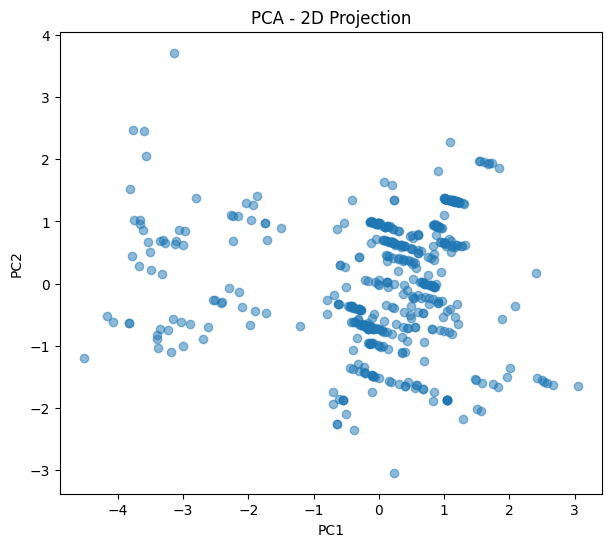

In [17]:
plt.figure(figsize=(7,6))

plt.scatter(
    X_pca_3[:,0],   # PC1
    X_pca_3[:,1],   # PC2
    alpha=0.5
)

plt.title("PCA - 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

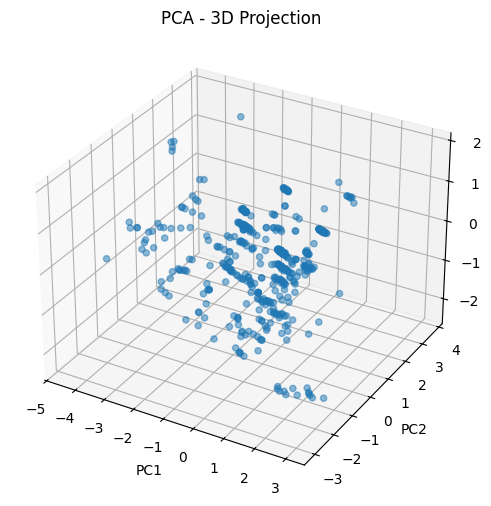

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3[:,0],
    X_pca_3[:,1],
    X_pca_3[:,2],
    alpha=0.5
)

ax.set_title("PCA - 3D Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("Cumulative Variance for all components:")
print(cumulative_variance)

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components to retain at least 95% variance:")
print(num_components_95)

Cumulative Variance for all components:
[0.42328939 0.67975091 0.91576803 1.         1.        ]
Number of components to retain at least 95% variance:
4


In [20]:
print("Eigenvalues:")
print(pca_full.explained_variance_)

Eigenvalues:
[1.69655066 1.02790188 0.94596042 0.33760307 0.        ]


In [21]:
print("Top 3 Eigenvalues:")
print(pca_full.explained_variance_[:3])

Top 3 Eigenvalues:
[1.69655066 1.02790188 0.94596042]
